# Surrogate Checkpoint Evaluation

For each `.pt` surrogate checkpoint in `checkpoints/`, computes the relative L2 error on the **physical** field U(t) and displays histograms/comparison plots.

Supports all surrogate types: `SLAEModel`, `LLAEModel`, `SLAESVDModel`, `LLAESVDModel`, `CorrectionAE`.

In [1]:
import sys, os
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')
sys.path.insert(0, os.path.join('..', 'src'))

import glob
import re
import gc
import numpy as np
import torch
import torch.nn.functional as F_nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from laplace_surrogate.inference.pipeline import InferencePipeline

## 1. Dataset loading

In [2]:
DATA_PATH  = '../dataset/ch4_rotated.npy'
DOE_PATH   = '../dataset/doe_rotated.npy'
SPLIT_PATH = '../dataset/split.npz'
CKPT_DIR   = '../checkpoints'
CACHE_DIR  = 'cache_surr'      # separate cache from AE notebook
N          = 128
DT         = 1.0

os.makedirs(CACHE_DIR, exist_ok=True)

# Raw field data (mmap)
U_raw = np.load(DATA_PATH, mmap_mode='r')          # (ns, Nt, H, W)
ns, Nt_full, H, W = U_raw.shape
print(f'Dataset: {ns} sims, Nt={Nt_full}, {H}×{W}')

# Physical parameters θ = (k, A, C)
doe = np.load(DOE_PATH)
theta_np = np.stack([doe['k'], doe['A'], doe['C']], axis=1).astype(np.float32)  # (ns, 3)
print(f'θ shape: {theta_np.shape}  min={theta_np.min():.3f}  max={theta_np.max():.3f}')

# Train/test split
split     = np.load(SPLIT_PATH)
test_idx  = split['test_idx'].tolist()
train_idx = [i for i in range(ns) if i not in set(test_idx)]
print(f'Train: {len(train_idx)}  Test: {len(test_idx)}')

Dataset: 8100 sims, Nt=150, 128×128
θ shape: (8100, 3)  min=0.000  max=350.000


Train: 6480  Test: 1620


In [3]:
def load_u(idx: int) -> np.ndarray:
    """Load and resize U to (Nt, N, N) float32."""
    u = U_raw[idx].astype(np.float32)
    if u.shape[-1] != N:
        u_t = torch.from_numpy(u).unsqueeze(1)
        u_t = F_nn.interpolate(u_t, size=(N, N), mode='bilinear', align_corners=False)
        u   = u_t.squeeze(1).numpy()
    return u

## 2. Evaluation function

`InferencePipeline` handles all model types transparently.

In [4]:
def eval_surrogate(ckpt_path: str, idx_list: list, device='cpu', batch_size: int = 32) -> np.ndarray:
    """
    Computes L2rel (%) on physical field U for every simulation in idx_list.
    Uses InferencePipeline so it works for any surrogate type.
    Returns np.ndarray of shape (n_samples,).
    """
    pipe = InferencePipeline.from_checkpoint(ckpt_path, device=device)
    name = os.path.basename(ckpt_path)

    l2rel_list = []
    for start in tqdm(range(0, len(idx_list), batch_size), desc=name, leave=False):
        batch_idx = idx_list[start:start + batch_size]
        theta_batch = theta_np[batch_idx]         # (B, 3)
        U_pred = pipe.predict(theta_batch)         # (B, Nt, N, N)

        for j, idx in enumerate(batch_idx):
            U_gt   = load_u(idx)                   # (Nt, N, N)
            denom  = np.linalg.norm(U_gt)
            if denom >= 1e-12:
                l2rel_list.append(
                    np.linalg.norm(U_pred[j] - U_gt) / denom * 100.0
                )

        if device == 'cuda':
            torch.cuda.empty_cache()

    pipe.model.cpu()
    del pipe
    if device == 'cuda':
        torch.cuda.empty_cache()
    gc.collect()
    return np.array(l2rel_list)

## 3. Evaluate all surrogate checkpoints

In [5]:
def _cache_path(name: str) -> str:
    return os.path.join(CACHE_DIR, f'{name}.npz')

def _cache_valid(cache_file: str, ckpt_path: str) -> bool:
    if not os.path.exists(cache_file):
        return False
    try:
        data = np.load(cache_file, allow_pickle=True)
        return float(data['ckpt_mtime']) == os.path.getmtime(ckpt_path)
    except Exception as e:
        print(f'Failed to load cache {cache_file}: {e}')
        return False

def _save_cache(name: str, ckpt_path: str, l2rel: np.ndarray):
    np.savez(
        _cache_path(name),
        l2rel      = l2rel,
        ckpt_mtime = np.float64(os.path.getmtime(ckpt_path)),
    )

def _load_cache(name: str) -> np.ndarray:
    return np.load(_cache_path(name))['l2rel']


def _model_type_from_ckpt(ckpt_path: str) -> str:
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    return ckpt.get('model_type', 'SLAEModel')


# ── Main loop ────────────────────────────────────────────────────────────
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}\n')

# Surrogate checkpoints are .pt files (AE checkpoints are .ckpt)
# Exclude svd_bases.pt which is not a surrogate
ckpt_paths = sorted([
    p for p in glob.glob(os.path.join(CKPT_DIR, '*.ckpt'))
    if (os.path.basename(p).startswith('SLAESVDModel') or os.path.basename(p).startswith('LLAESVDModel'))
      and not os.path.basename(p).startswith('svd_bases')
])
print(f'{len(ckpt_paths)} surrogate checkpoints found:')
for p in ckpt_paths:
    print(' ', os.path.basename(p))

Device: cuda

26 surrogate checkpoints found:
  LLAESVDModel__llae_ld128_K16_g0.01__t4h2_ksvd16.ckpt
  LLAESVDModel__llae_ld128_K16_g0.01__t4h2_ksvd32.ckpt
  LLAESVDModel__llae_ld32_K16_g0.01__t4h2_ksvd16.ckpt
  LLAESVDModel__llae_ld64_K16_g0.001__t4h2_ksvd16.ckpt
  LLAESVDModel__llae_ld64_K16_g0.001__t4h2_ksvd32.ckpt
  LLAESVDModel__llae_ld64_K16_g0.01__t4h2_ksvd16.ckpt
  LLAESVDModel__llae_ld64_K16_g0.01__t4h2_ksvd32.ckpt
  LLAESVDModel__llae_ld64_K16_g0.0__t4h2_ksvd16.ckpt
  LLAESVDModel__llae_ld64_K16_g0.0__t4h2_ksvd32.ckpt
  LLAESVDModel__llae_ld64_K32_g0.01__t4h2_ksvd16.ckpt
  LLAESVDModel__llae_ld64_K32_g0.01__t4h2_ksvd32.ckpt
  LLAESVDModel__llae_ld64_K8_g0.01__t4h2_ksvd16.ckpt
  LLAESVDModel__llae_ld64_K8_g0.01__t4h2_ksvd32.ckpt
  SLAESVDModel__slae_ld128_K16_g0.01__t4h2_ksvd16.ckpt
  SLAESVDModel__slae_ld128_K16_g0.01__t4h2_ksvd32.ckpt
  SLAESVDModel__slae_ld32_K16_g0.01__t4h2_ksvd16.ckpt
  SLAESVDModel__slae_ld64_K16_g0.001__t4h2_ksvd16.ckpt
  SLAESVDModel__slae_ld64_K16_g0.

In [6]:
results     = {}   # name → np.array L2rel (%)
model_types = {}   # name → model_type str

for ckpt_path in ckpt_paths:
    name       = os.path.splitext(os.path.basename(ckpt_path))[0]
    cache_file = _cache_path(name)

    mtype = _model_type_from_ckpt(ckpt_path)
    model_types[name] = mtype

    if _cache_valid(cache_file, ckpt_path):
        l2 = _load_cache(name)
        print(f'[cache]   {name}  [{mtype}]')
    else:
        print(f'[compute] {name}  [{mtype}]')
        try:
            l2 = eval_surrogate(ckpt_path, test_idx, device=device)
            _save_cache(name, ckpt_path, l2)
        except Exception as e:
            print(f'   ERROR: {e}')
            continue

    results[name] = l2
    print(f'   median={np.median(l2):.2f}%  mean={np.mean(l2):.2f}%  '
          f'p90={np.percentile(l2,90):.2f}%  n={len(l2)}')

print('\nDone.')

[cache]   LLAESVDModel__llae_ld128_K16_g0.01__t4h2_ksvd16  [LLAESVDModel]
   median=5.83%  mean=6.51%  p90=9.48%  n=1620
[cache]   LLAESVDModel__llae_ld128_K16_g0.01__t4h2_ksvd32  [LLAESVDModel]
   median=4.77%  mean=5.30%  p90=7.82%  n=1620
[cache]   LLAESVDModel__llae_ld32_K16_g0.01__t4h2_ksvd16  [LLAESVDModel]
   median=5.55%  mean=6.29%  p90=9.39%  n=1620
[cache]   LLAESVDModel__llae_ld64_K16_g0.001__t4h2_ksvd16  [LLAESVDModel]
   median=5.90%  mean=6.72%  p90=9.92%  n=1620
[cache]   LLAESVDModel__llae_ld64_K16_g0.001__t4h2_ksvd32  [LLAESVDModel]
   median=4.44%  mean=4.96%  p90=7.41%  n=1620


[cache]   LLAESVDModel__llae_ld64_K16_g0.01__t4h2_ksvd16  [LLAESVDModel]
   median=5.84%  mean=6.58%  p90=9.79%  n=1620
[cache]   LLAESVDModel__llae_ld64_K16_g0.01__t4h2_ksvd32  [LLAESVDModel]
   median=4.24%  mean=4.61%  p90=6.75%  n=1620
[cache]   LLAESVDModel__llae_ld64_K16_g0.0__t4h2_ksvd16  [LLAESVDModel]
   median=5.94%  mean=6.76%  p90=10.18%  n=1620
[cache]   LLAESVDModel__llae_ld64_K16_g0.0__t4h2_ksvd32  [LLAESVDModel]
   median=4.50%  mean=4.97%  p90=7.29%  n=1620
[cache]   LLAESVDModel__llae_ld64_K32_g0.01__t4h2_ksvd16  [LLAESVDModel]
   median=5.58%  mean=6.22%  p90=9.35%  n=1620
[cache]   LLAESVDModel__llae_ld64_K32_g0.01__t4h2_ksvd32  [LLAESVDModel]
   median=4.29%  mean=4.69%  p90=7.02%  n=1620
[cache]   LLAESVDModel__llae_ld64_K8_g0.01__t4h2_ksvd16  [LLAESVDModel]
   median=6.54%  mean=7.37%  p90=11.05%  n=1620
[cache]   LLAESVDModel__llae_ld64_K8_g0.01__t4h2_ksvd32  [LLAESVDModel]
   median=4.60%  mean=5.04%  p90=7.47%  n=1620
[cache]   SLAESVDModel__slae_ld128_K16_g0.

## 4. Histograms per checkpoint

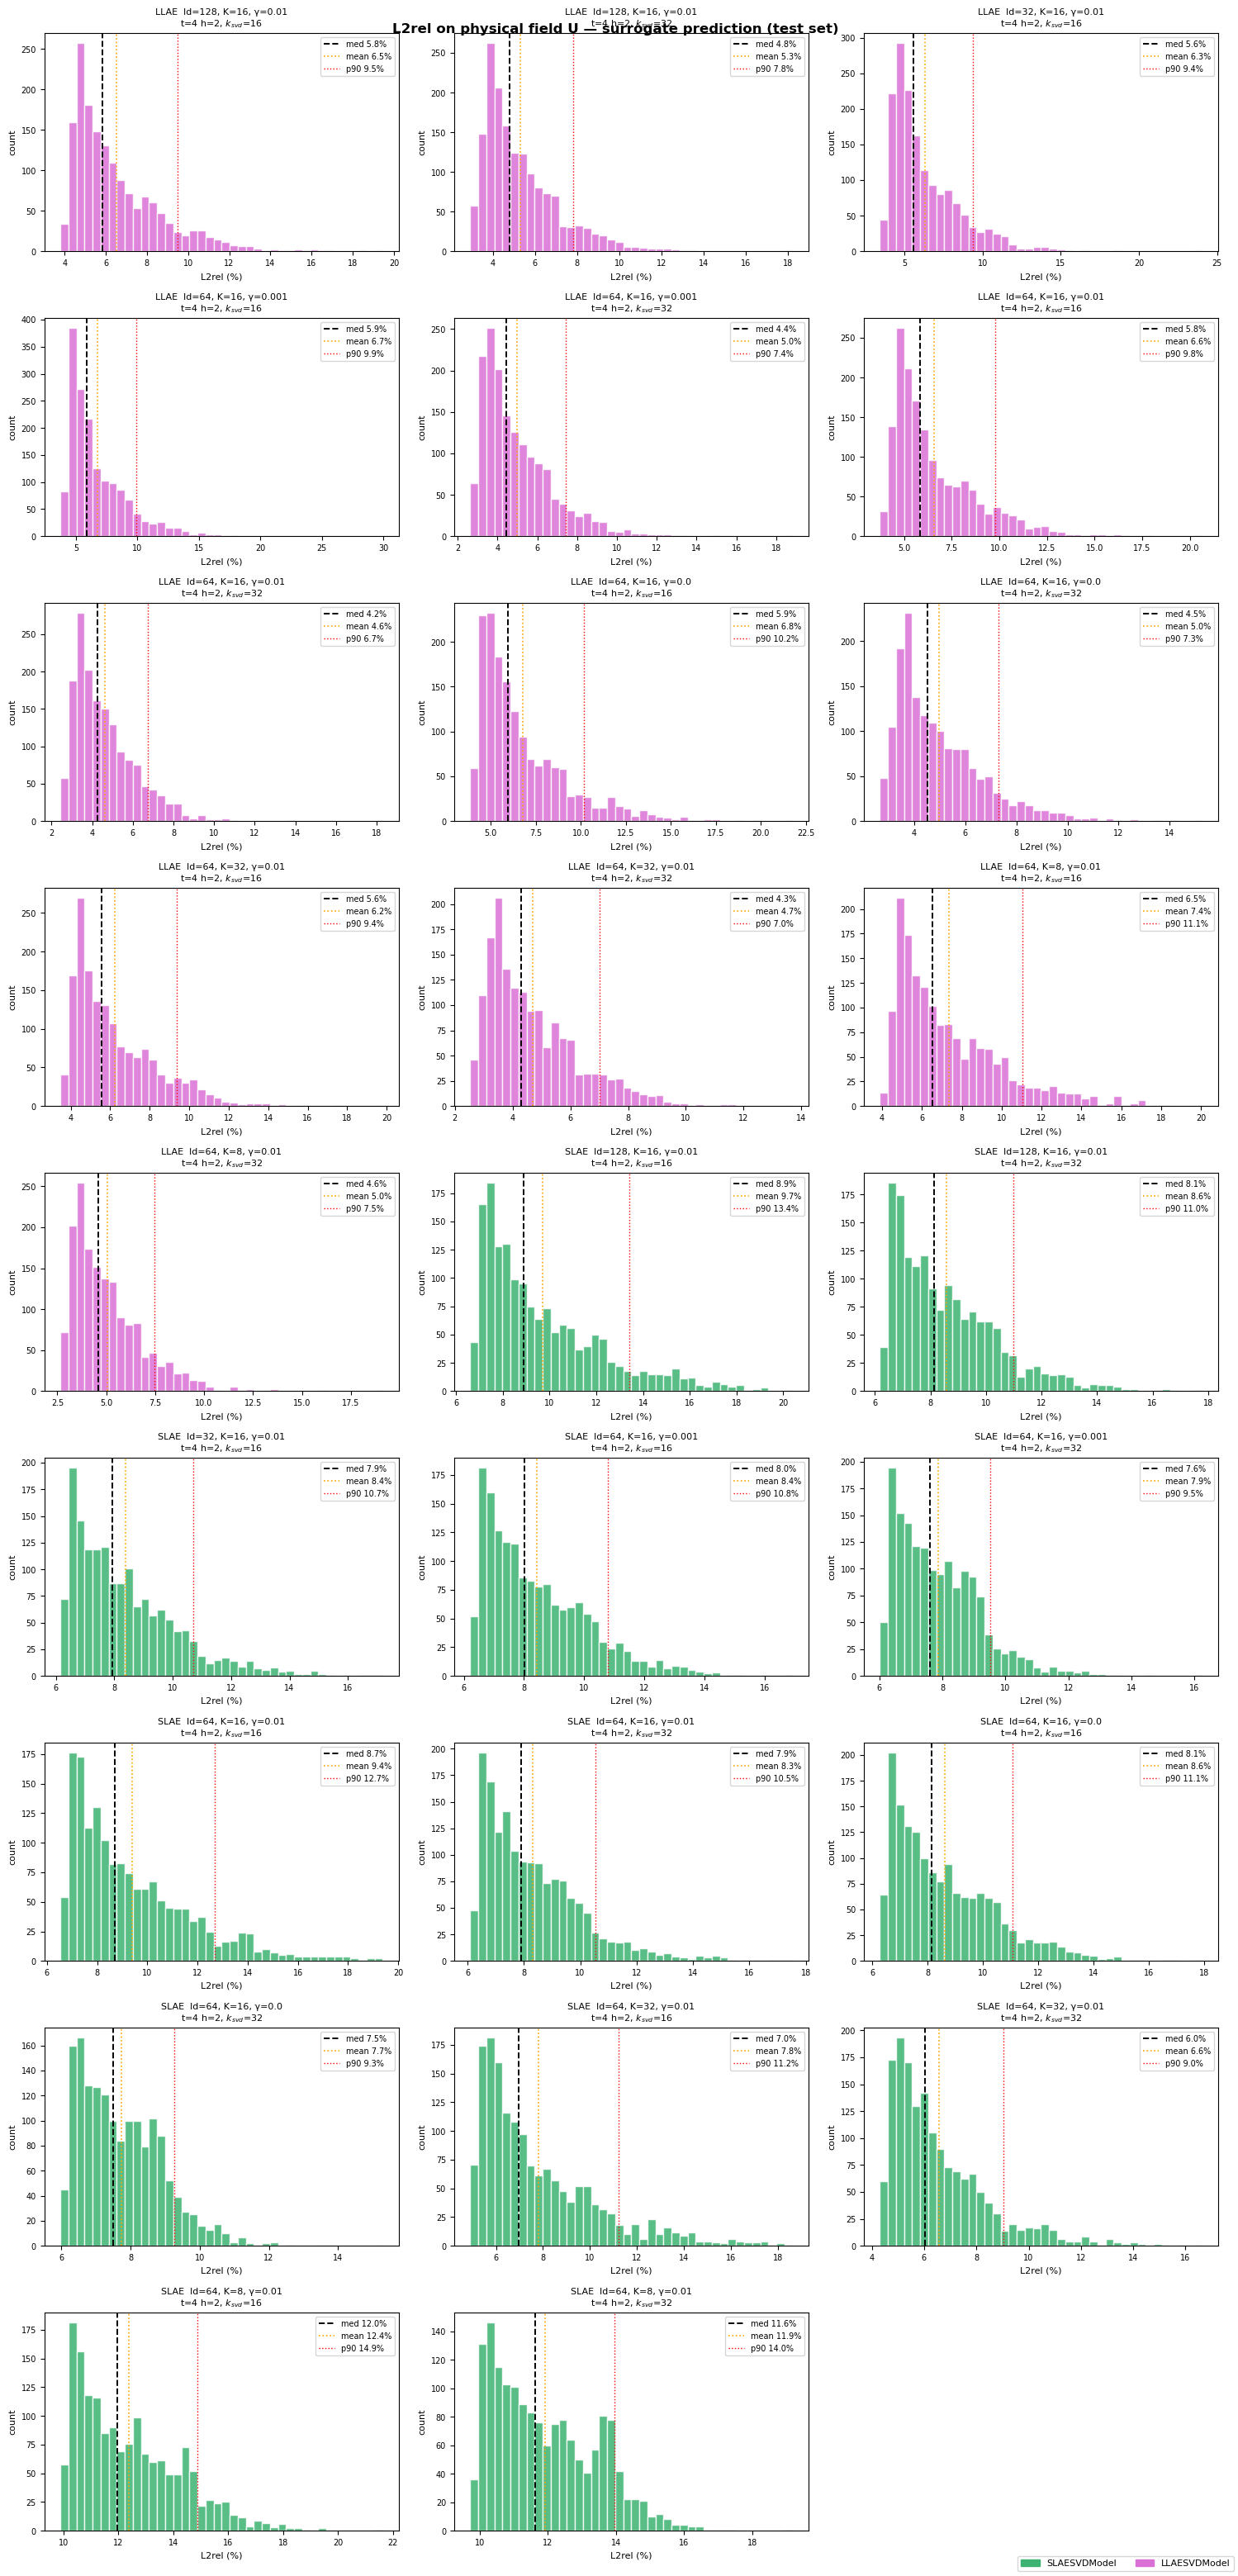

In [29]:

if results:
    names  = list(results.keys())
    n_ckpt = len(names)
    ncols  = min(3, n_ckpt)
    nrows  = (n_ckpt + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
    if n_ckpt == 1:
        axes = np.array([axes])
    axes = np.array(axes).flatten()

    for ax, name in zip(axes, names):
        l2     = results[name]
        mtype  = model_types.get(name, 'SLAEModel')
        color  = PALETTE.get(mtype, 'gray')
        median = np.median(l2)
        mean   = np.mean(l2)
        p90    = np.percentile(l2, 90)

        ax.hist(l2, bins=40, color=color, edgecolor='white', alpha=0.85)
        ax.axvline(median, color='black',  linestyle='--', linewidth=1.4, label=f'med {median:.1f}%')
        ax.axvline(mean,   color='orange', linestyle=':',  linewidth=1.2, label=f'mean {mean:.1f}%')
        ax.axvline(p90,    color='red',    linestyle=':',  linewidth=1.0, label=f'p90 {p90:.1f}%')
        ax.set_title(_pretty_name(name), fontsize=8)
        ax.set_xlabel('L2rel (%)', fontsize=8)
        ax.set_ylabel('count', fontsize=8)
        ax.legend(fontsize=7)
        ax.tick_params(labelsize=7)

    for ax in axes[n_ckpt:]:
        ax.set_visible(False)

    from matplotlib.patches import Patch
    legend_handles = [Patch(color=c, label=k) for k, c in PALETTE.items() if k in model_types.values()]
    fig.legend(handles=legend_handles, loc='lower right', fontsize=8, ncol=2)

    fig.suptitle('L2rel on physical field U — surrogate prediction (test set)', fontsize=12, fontweight='bold')
    fig.tight_layout()
    plt.show()
else:
    print('No surrogate checkpoints found in', CKPT_DIR)


## 5. Median comparison

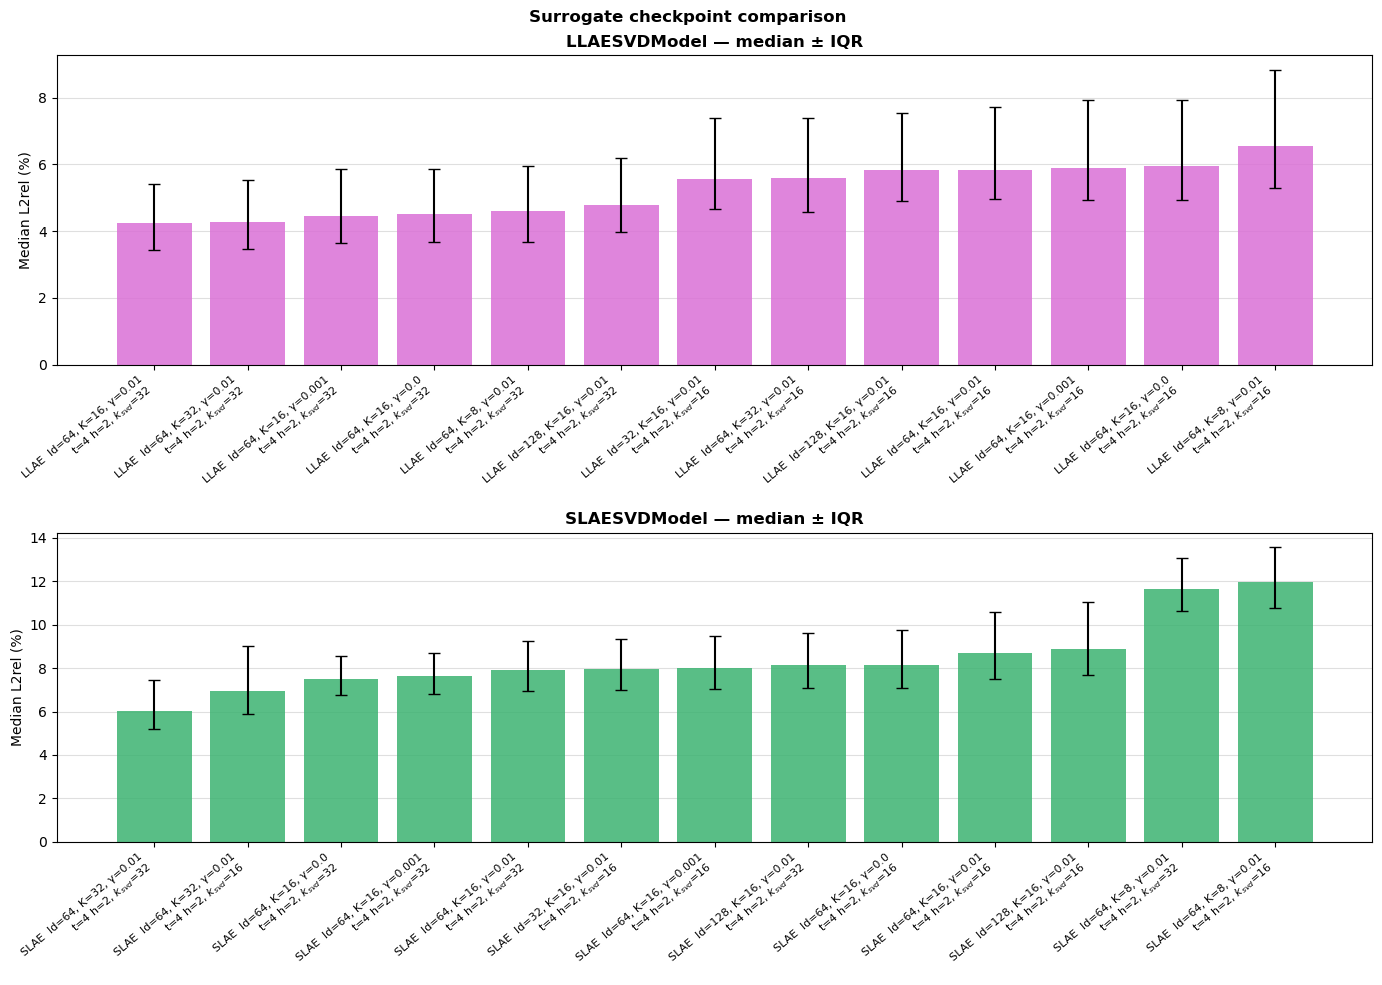

In [24]:
if results:
    medians = {n: float(np.median(v)) for n, v in results.items()}
    p25     = {n: float(np.percentile(v, 25)) for n, v in results.items()}
    p75     = {n: float(np.percentile(v, 75)) for n, v in results.items()}

    families = sorted(set(model_types.values()))
    fig, axes = plt.subplots(len(families), 1, figsize=(14, 5 * len(families)))
    if len(families) == 1:
        axes = [axes]

    for ax, family in zip(axes, families):
        names_fam    = [n for n in results if model_types.get(n) == family]
        sorted_names = sorted(names_fam, key=lambda n: medians[n])
        color        = PALETTE.get(family, 'gray')
        x            = np.arange(len(sorted_names))

        ax.bar(x, [medians[n] for n in sorted_names], color=color, alpha=0.85, zorder=2)

        yerr_low  = [medians[n] - p25[n] for n in sorted_names]
        yerr_high = [p75[n] - medians[n] for n in sorted_names]
        ax.errorbar(x, [medians[n] for n in sorted_names],
                    yerr=[yerr_low, yerr_high],
                    fmt='none', color='black', capsize=4, linewidth=1.5, zorder=3)

        ax.set_xticks(x)
        ax.set_xticklabels([_pretty_name(n) for n in sorted_names],
                           rotation=40, ha='right', fontsize=8)
        ax.set_ylabel('Median L2rel (%)')
        ax.set_title(f'{family} — median ± IQR', fontweight='bold')
        ax.grid(axis='y', alpha=0.4, zorder=0)

    fig.suptitle('Surrogate checkpoint comparison', fontweight='bold', fontsize=12)
    fig.tight_layout()
    plt.show()

## 6. Summary table

In [15]:
if results:
    print(f"{'Config':<60}  {'type':<15}  {'median':>8}  {'mean':>8}  {'p90':>8}  {'n':>5}")
    print('-' * 150)
    for n in sorted(results, key=lambda n: np.median(results[n])):
        l2    = results[n]
        mtype = model_types.get(n, '?')
        label = _pretty_name(n).replace('\n', '  ')
        print(f'{label:<60}  {mtype:<15}  {np.median(l2):>7.2f}%  {np.mean(l2):>7.2f}%  '
              f'{np.percentile(l2,90):>7.2f}%  {len(l2):>5}')

Config                                                        type               median      mean       p90      n
------------------------------------------------------------------------------------------------------------------------------------------------------
LLAE  ld=64, K=16, γ=0.01  t=4 h=2, $k_{svd}$=32              LLAESVDModel        4.24%     4.61%     6.75%   1620
LLAE  ld=64, K=32, γ=0.01  t=4 h=2, $k_{svd}$=32              LLAESVDModel        4.29%     4.69%     7.02%   1620
LLAE  ld=64, K=16, γ=0.001  t=4 h=2, $k_{svd}$=32             LLAESVDModel        4.44%     4.96%     7.41%   1620
LLAE  ld=64, K=16, γ=0.0  t=4 h=2, $k_{svd}$=32               LLAESVDModel        4.50%     4.97%     7.29%   1620
LLAE  ld=64, K=8, γ=0.01  t=4 h=2, $k_{svd}$=32               LLAESVDModel        4.60%     5.04%     7.47%   1620
LLAE  ld=128, K=16, γ=0.01  t=4 h=2, $k_{svd}$=32             LLAESVDModel        4.77%     5.30%     7.82%   1620
LLAE  ld=32, K=16, γ=0.01  t=4 h=2, $k_{svd}

## 7. Family ablation plots

Violin plots showing the effect of each hyperparameter, grouping by model family.

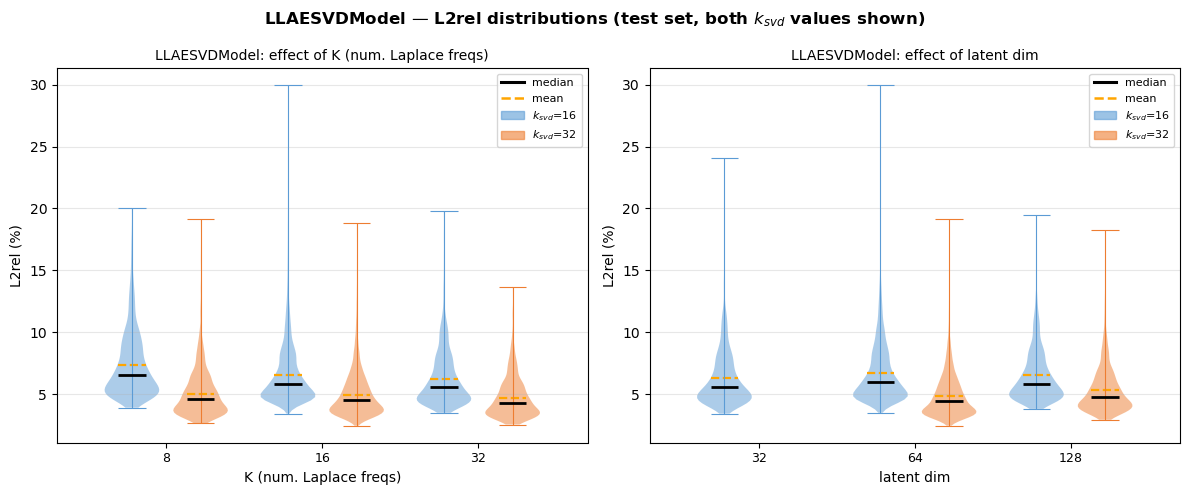

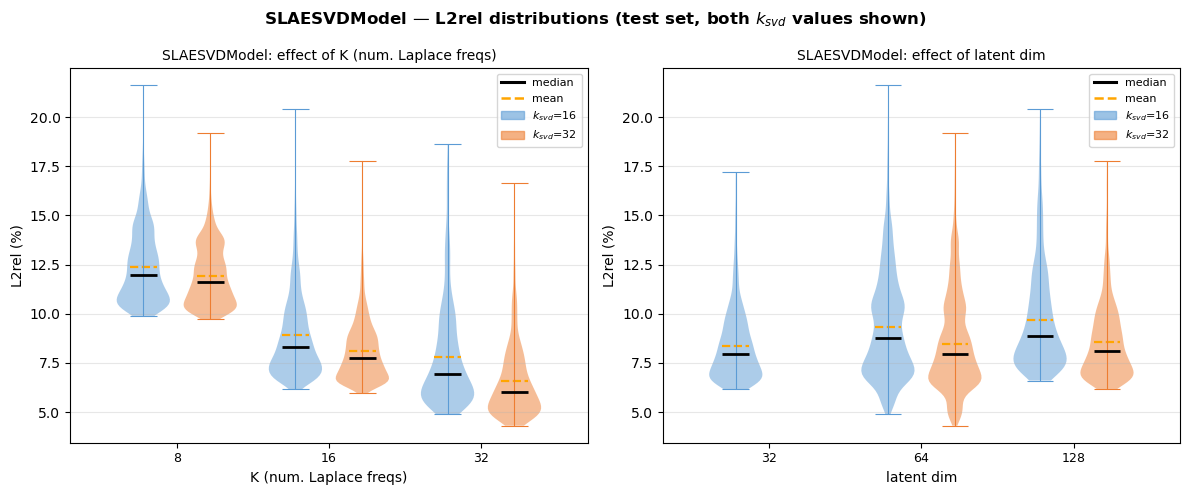

In [21]:
from collections import defaultdict
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Parse surrogate checkpoint name into structured dict
def _parse_surr_name(name: str) -> dict | None:
    m = _SURR_PAT.match(name)
    if not m:
        return None
    ae_stem = m.group('ae_stem')
    cls     = m.group('cls')

    ae_m = re.match(r'^(?P<ae>[a-z]+)_ld(?P<ld>\d+)_K(?P<K>\d+)_g(?P<g>[0-9.]+)(?P<ae_suf>.*)', ae_stem)
    if not ae_m:
        return None

    suffix  = m.group('suffix')
    ksvd_m  = re.search(r'ksvd(\d+)', suffix)
    k_svd   = int(ksvd_m.group(1)) if ksvd_m else None

    return {
        'name'   : name,
        'cls'    : cls,
        'ae'     : ae_m.group('ae'),
        'ld'     : int(ae_m.group('ld')),
        'K'      : int(ae_m.group('K')),
        'gamma'  : float(ae_m.group('g')),
        'n_trunk': int(m.group('n_trunk')),
        'n_head' : int(m.group('n_head')),
        'k_svd'  : k_svd,
    }

parsed_rows = [r for r in (_parse_surr_name(n) for n in results) if r is not None]

# Two colors for the two k_svd values (lo / hi), ranked by value
KSVD_COLORS = ['#5B9BD5', '#ED7D31']


def _violin_ablation(ax, rows, var_name, xlabel, title):
    """Draw grouped violins, one per k_svd value, side by side for each x-tick."""
    if not rows:
        ax.set_title(f"{title}\n(no data)"); ax.axis('off'); return

    ksvd_vals = sorted(set(r['k_svd'] for r in rows if r['k_svd'] is not None))
    has_ksvd  = len(ksvd_vals) >= 2
    n_ksvd    = len(ksvd_vals) if has_ksvd else 1
    width     = 0.35 if has_ksvd else 0.65
    spread    = 0.22  # half-distance between the two violins

    xs_vals = sorted(set(r[var_name] for r in rows))

    legend_handles = [
        Line2D([0], [0], color='black',  linewidth=2.2,              label='median'),
        Line2D([0], [0], color='orange', linewidth=1.8, linestyle='--', label='mean'),
    ]

    for ki, ksvd in enumerate(ksvd_vals if has_ksvd else [None]):
        color   = KSVD_COLORS[ki] if has_ksvd else '#888888'
        offset  = (ki - (n_ksvd - 1) / 2) * spread * 2  # centers the group

        sub = [r for r in rows if (r['k_svd'] == ksvd if has_ksvd else True)]
        groups = defaultdict(list)
        for r in sub:
            groups[r[var_name]].extend(results[r['name']].tolist())

        positions = [i + offset for i, v in enumerate(xs_vals) if v in groups]
        datasets  = [groups[v] for v in xs_vals if v in groups]
        if not datasets:
            continue

        parts = ax.violinplot(datasets, positions=positions, widths=width,
                              showmedians=True, showmeans=True, showextrema=True)
        for pc in parts['bodies']:
            pc.set_facecolor(color); pc.set_alpha(0.5)
        parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(2.0)
        parts['cmeans'].set_color('orange');  parts['cmeans'].set_linewidth(1.6)
        parts['cmeans'].set_linestyle('--')
        for key in ('cmaxes', 'cmins', 'cbars'):
            parts[key].set_color(color); parts[key].set_linewidth(0.8)

        if has_ksvd:
            legend_handles.append(Patch(color=color, alpha=0.6, label=f'$k_{{svd}}$={ksvd}'))

    ax.set_xticks(range(len(xs_vals)))
    ax.set_xticklabels([str(v) for v in xs_vals], fontsize=9)
    ax.set_xlim(-0.7, len(xs_vals) - 0.3)
    ax.legend(handles=legend_handles, fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('L2rel (%)')
    ax.grid(alpha=0.3, axis='y')


# One figure per family; ablations: K, ld, n_trunk (k_svd shown via colors, not as a separate violin)
families = sorted(set(r['cls'] for r in parsed_rows))

for family in families:
    frows = [r for r in parsed_rows if r['cls'] == family]
    if not frows:
        continue

    ablations = []
    for var, xlabel in [
        ('K',      'K (num. Laplace freqs)'),
        ('ld',     'latent dim'),
        ('n_trunk','n_trunk'),
    ]:
        if len(set(r[var] for r in frows)) > 1:
            ablations.append((var, xlabel))

    if not ablations:
        print(f'{family}: only one configuration found, skipping ablation plot.')
        continue

    fig, axes = plt.subplots(1, len(ablations), figsize=(6 * len(ablations), 5))
    if len(ablations) == 1:
        axes = [axes]

    for ax, (var, xlabel) in zip(axes, ablations):
        _violin_ablation(ax, frows, var, xlabel, f'{family}: effect of {xlabel}')

    fig.suptitle(f'{family} — L2rel distributions (test set, both $k_{{svd}}$ values shown)',
                 fontweight='bold')
    fig.tight_layout()
    plt.show()

## 7b. $k_{svd}$ impact — paired comparison

For each config (family, ld, K, γ), both $k_{svd}$ values are paired.  
**Left**: scatter med(ksvd_lo) vs med(ksvd_hi) — points below the diagonal mean larger $k_{svd}$ is better.  
**Right**: gain Δ = med(ksvd_lo) − med(ksvd_hi) per config, sorted — shows the magnitude and consistency of the gain.

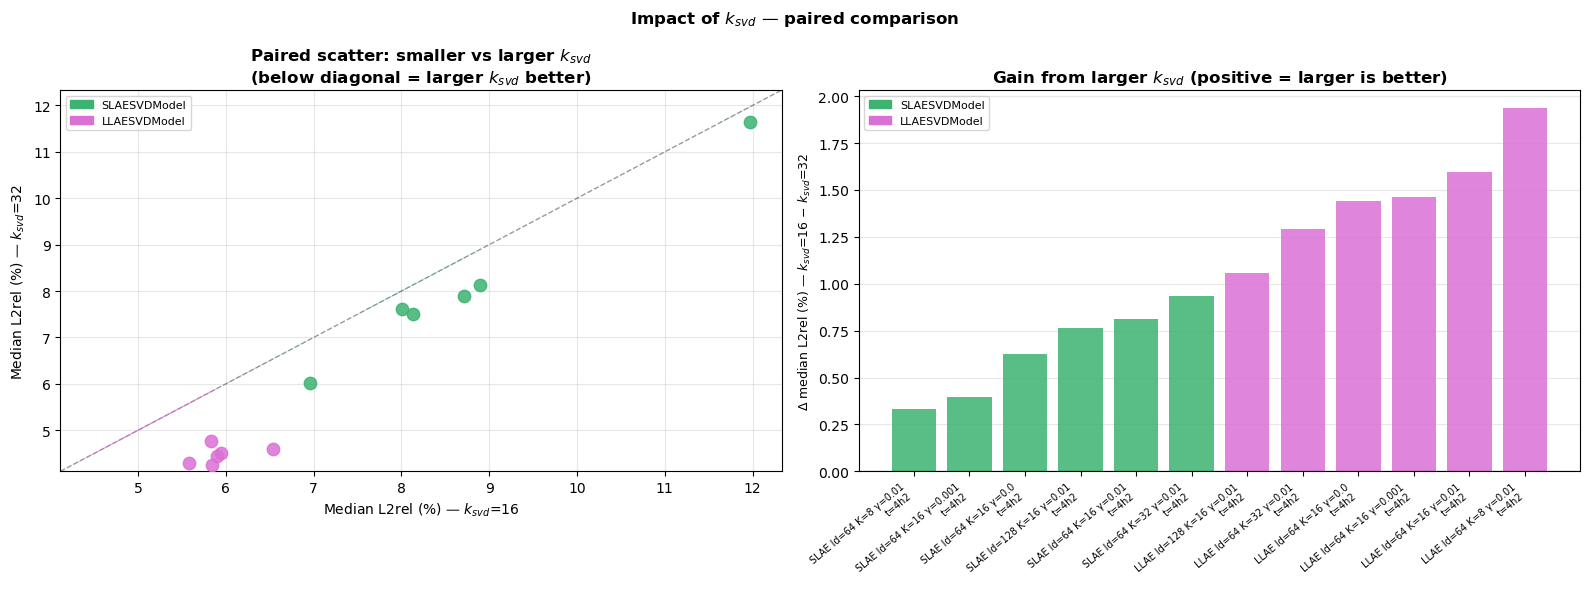

Config                                         ksvd_lo  ksvd_hi   med_lo   med_hi       Δ
------------------------------------------------------------------------------------------
LLAE ld=64 K=8 γ=0.01  t=4h2                        16       32    6.54%    4.60%  +1.94%
LLAE ld=64 K=16 γ=0.01  t=4h2                       16       32    5.84%    4.24%  +1.59%
LLAE ld=64 K=16 γ=0.001  t=4h2                      16       32    5.90%    4.44%  +1.46%
LLAE ld=64 K=16 γ=0.0  t=4h2                        16       32    5.94%    4.50%  +1.44%
LLAE ld=64 K=32 γ=0.01  t=4h2                       16       32    5.58%    4.29%  +1.29%
LLAE ld=128 K=16 γ=0.01  t=4h2                      16       32    5.83%    4.77%  +1.06%
SLAE ld=64 K=32 γ=0.01  t=4h2                       16       32    6.96%    6.03%  +0.93%
SLAE ld=64 K=16 γ=0.01  t=4h2                       16       32    8.71%    7.90%  +0.81%
SLAE ld=128 K=16 γ=0.01  t=4h2                      16       32    8.89%    8.12%  +0.77%
SLAE ld=6

In [20]:
if parsed_rows:
    medians = {n: float(np.median(v)) for n, v in results.items()}

    # Build pairs: group by (cls, ae, ld, K, gamma, n_trunk, n_head), collect k_svd variants
    from itertools import combinations
    pair_key = lambda r: (r['cls'], r['ae'], r['ld'], r['K'], r['gamma'], r['n_trunk'], r['n_head'])

    groups = defaultdict(dict)
    for r in parsed_rows:
        if r['k_svd'] is not None:
            groups[pair_key(r)][r['k_svd']] = r['name']

    # Keep only groups with exactly 2 k_svd values
    pairs = [(k, v) for k, v in groups.items() if len(v) == 2]

    if not pairs:
        print('No paired k_svd configs found.')
    else:
        # For each pair: lo = smaller k_svd, hi = larger k_svd
        pair_data = []
        for key, ksvd_map in pairs:
            ksvd_vals = sorted(ksvd_map)
            lo, hi    = ksvd_vals[0], ksvd_vals[1]
            med_lo    = medians[ksvd_map[lo]]
            med_hi    = medians[ksvd_map[hi]]
            cls       = key[0]
            label     = (f'{key[1].upper()} ld={key[2]} K={key[3]} γ={key[4]}'
                         f'\nt={key[5]}h{key[6]}')
            pair_data.append(dict(cls=cls, lo=lo, hi=hi,
                                  med_lo=med_lo, med_hi=med_hi,
                                  delta=med_lo - med_hi, label=label))

        pair_data.sort(key=lambda d: d['delta'])

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        # ── Scatter med(lo) vs med(hi) ────────────────────────────────────
        all_vals = [d['med_lo'] for d in pair_data] + [d['med_hi'] for d in pair_data]
        vmin, vmax = min(all_vals) * 0.97, max(all_vals) * 1.03
        ax1.plot([vmin, vmax], [vmin, vmax], 'k--', linewidth=1, alpha=0.4, label='y = x')

        for d in pair_data:
            c = PALETTE.get(d['cls'], 'gray')
            ax1.scatter(d['med_lo'], d['med_hi'], color=c, s=80, zorder=3, alpha=0.85)
            # connect to diagonal with a thin line
            ax1.plot([d['med_lo'], d['med_hi']], [d['med_lo'], d['med_hi']],
                     color=c, linewidth=0.5, alpha=0.3, zorder=2)

        ax1.set_xlim(vmin, vmax); ax1.set_ylim(vmin, vmax)
        ax1.set_xlabel(f'Median L2rel (%) — $k_{{svd}}$={pair_data[0]["lo"]}', fontsize=10)
        ax1.set_ylabel(f'Median L2rel (%) — $k_{{svd}}$={pair_data[0]["hi"]}', fontsize=10)
        ax1.set_title('Paired scatter: smaller vs larger $k_{svd}$\n(below diagonal = larger $k_{svd}$ better)',
                      fontweight='bold')
        ax1.grid(alpha=0.3)

        from matplotlib.patches import Patch
        legend_handles = [Patch(color=c, label=k) for k, c in PALETTE.items()
                          if k in {d['cls'] for d in pair_data}]
        ax1.legend(handles=legend_handles, fontsize=8)

        # ── Delta bar chart ───────────────────────────────────────────────
        x      = np.arange(len(pair_data))
        colors = [PALETTE.get(d['cls'], 'gray') for d in pair_data]
        bars   = ax2.bar(x, [d['delta'] for d in pair_data], color=colors, alpha=0.85, zorder=2)
        ax2.axhline(0, color='black', linewidth=0.8, zorder=3)

        ax2.set_xticks(x)
        ax2.set_xticklabels([d['label'] for d in pair_data],
                            rotation=40, ha='right', fontsize=7)
        ax2.set_ylabel(f'Δ median L2rel (%) — $k_{{svd}}$={pair_data[0]["lo"]} − $k_{{svd}}$={pair_data[0]["hi"]}',
                       fontsize=9)
        ax2.set_title('Gain from larger $k_{svd}$ (positive = larger is better)',
                      fontweight='bold')
        ax2.grid(axis='y', alpha=0.3, zorder=0)
        ax2.legend(handles=legend_handles, fontsize=8)

        fig.suptitle('Impact of $k_{svd}$ — paired comparison', fontweight='bold', fontsize=12)
        fig.tight_layout()
        plt.show()

        # Summary
        print(f'{"Config":<45}  {"ksvd_lo":>7}  {"ksvd_hi":>7}  {"med_lo":>7}  {"med_hi":>7}  {"Δ":>6}')
        print('-' * 90)
        for d in sorted(pair_data, key=lambda d: -d['delta']):
            print(f'{d["label"].replace(chr(10), "  "):<45}  '
                  f'{d["lo"]:>7}  {d["hi"]:>7}  '
                  f'{d["med_lo"]:>6.2f}%  {d["med_hi"]:>6.2f}%  {d["delta"]:>+5.2f}%')

## 8. Inference latency benchmark

In [22]:
N_BENCH      = 200
N_WARMUP_LAT = 10
N_RUNS_LAT   = 50

# Pre-load theta for the benchmark samples (lightweight, no U needed for surrogate)
bench_theta = theta_np[test_idx[:N_BENCH]]   # (N_BENCH, 3)
print(f'Benchmark theta shape: {bench_theta.shape}')

bench = {}

def _time_gpu(fn, n_warmup, n_runs):
    for _ in range(n_warmup):
        fn()
    torch.cuda.synchronize()
    ev_s = torch.cuda.Event(enable_timing=True)
    ev_e = torch.cuda.Event(enable_timing=True)
    ms = []
    for _ in range(n_runs):
        ev_s.record(); fn(); ev_e.record()
        torch.cuda.synchronize()
        ms.append(ev_s.elapsed_time(ev_e))
    return np.array(ms)


for ckpt_path in tqdm(ckpt_paths, desc='latency benchmark'):
    name = os.path.splitext(os.path.basename(ckpt_path))[0]
    try:
        pipe  = InferencePipeline.from_checkpoint(ckpt_path, device=device)
        theta_dev = torch.tensor(bench_theta[:1], dtype=torch.float32, device=device)
        theta_mean = torch.tensor(pipe.ckpt['theta_mean'], dtype=torch.float32, device=device)
        theta_std  = torch.tensor(pipe.ckpt['theta_std'],  dtype=torch.float32, device=device)
        theta_norm = (theta_dev - theta_mean) / theta_std

        if device == 'cuda':
            def lat_fn():
                with torch.no_grad():
                    pipe.model.generate(theta_norm)
            lat_ms = _time_gpu(lat_fn, N_WARMUP_LAT, N_RUNS_LAT)
            bench[name] = dict(lat_med=np.median(lat_ms), lat_std=np.std(lat_ms))
        else:
            import time
            times = []
            for _ in range(N_RUNS_LAT + N_WARMUP_LAT):
                t0 = time.perf_counter()
                with torch.no_grad():
                    pipe.model.generate(theta_norm)
                times.append((time.perf_counter() - t0) * 1e3)
            times = np.array(times[N_WARMUP_LAT:])
            bench[name] = dict(lat_med=np.median(times), lat_std=np.std(times))

        mtype = pipe.model_type
        print(f'{name:<55}  lat={bench[name]["lat_med"]:6.1f}±{bench[name]["lat_std"]:.1f} ms  [{mtype}]')

        pipe.model.cpu(); del pipe
        if device == 'cuda': torch.cuda.empty_cache()
        gc.collect()

    except Exception as e:
        print(f'{name}  ERROR: {e}')

print('\nDone.')

Benchmark theta shape: (200, 3)


latency benchmark:   0%|          | 0/26 [00:00<?, ?it/s]

/tmp/ipykernel_469806/3404931686.py:30: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta_mean = torch.tensor(pipe.ckpt['theta_mean'], dtype=torch.float32, device=device)
/tmp/ipykernel_469806/3404931686.py:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta_std  = torch.tensor(pipe.ckpt['theta_std'],  dtype=torch.float32, device=device)


LLAESVDModel__llae_ld128_K16_g0.01__t4h2_ksvd16          lat=  22.1±3.5 ms  [LLAESVDModel]
LLAESVDModel__llae_ld128_K16_g0.01__t4h2_ksvd32          lat=  22.1±2.9 ms  [LLAESVDModel]
LLAESVDModel__llae_ld32_K16_g0.01__t4h2_ksvd16           lat=  21.6±3.6 ms  [LLAESVDModel]
LLAESVDModel__llae_ld64_K16_g0.001__t4h2_ksvd16          lat=  21.9±3.1 ms  [LLAESVDModel]
LLAESVDModel__llae_ld64_K16_g0.001__t4h2_ksvd32          lat=  21.8±3.3 ms  [LLAESVDModel]
LLAESVDModel__llae_ld64_K16_g0.01__t4h2_ksvd16           lat=  22.0±3.5 ms  [LLAESVDModel]
LLAESVDModel__llae_ld64_K16_g0.01__t4h2_ksvd32           lat=  21.9±4.3 ms  [LLAESVDModel]
LLAESVDModel__llae_ld64_K16_g0.0__t4h2_ksvd16            lat=  22.2±2.7 ms  [LLAESVDModel]
LLAESVDModel__llae_ld64_K16_g0.0__t4h2_ksvd32            lat=  22.2±3.2 ms  [LLAESVDModel]
LLAESVDModel__llae_ld64_K32_g0.01__t4h2_ksvd16           lat=  22.4±3.4 ms  [LLAESVDModel]
LLAESVDModel__llae_ld64_K32_g0.01__t4h2_ksvd32           lat=  22.5±2.5 ms  [LLAESVDModel]

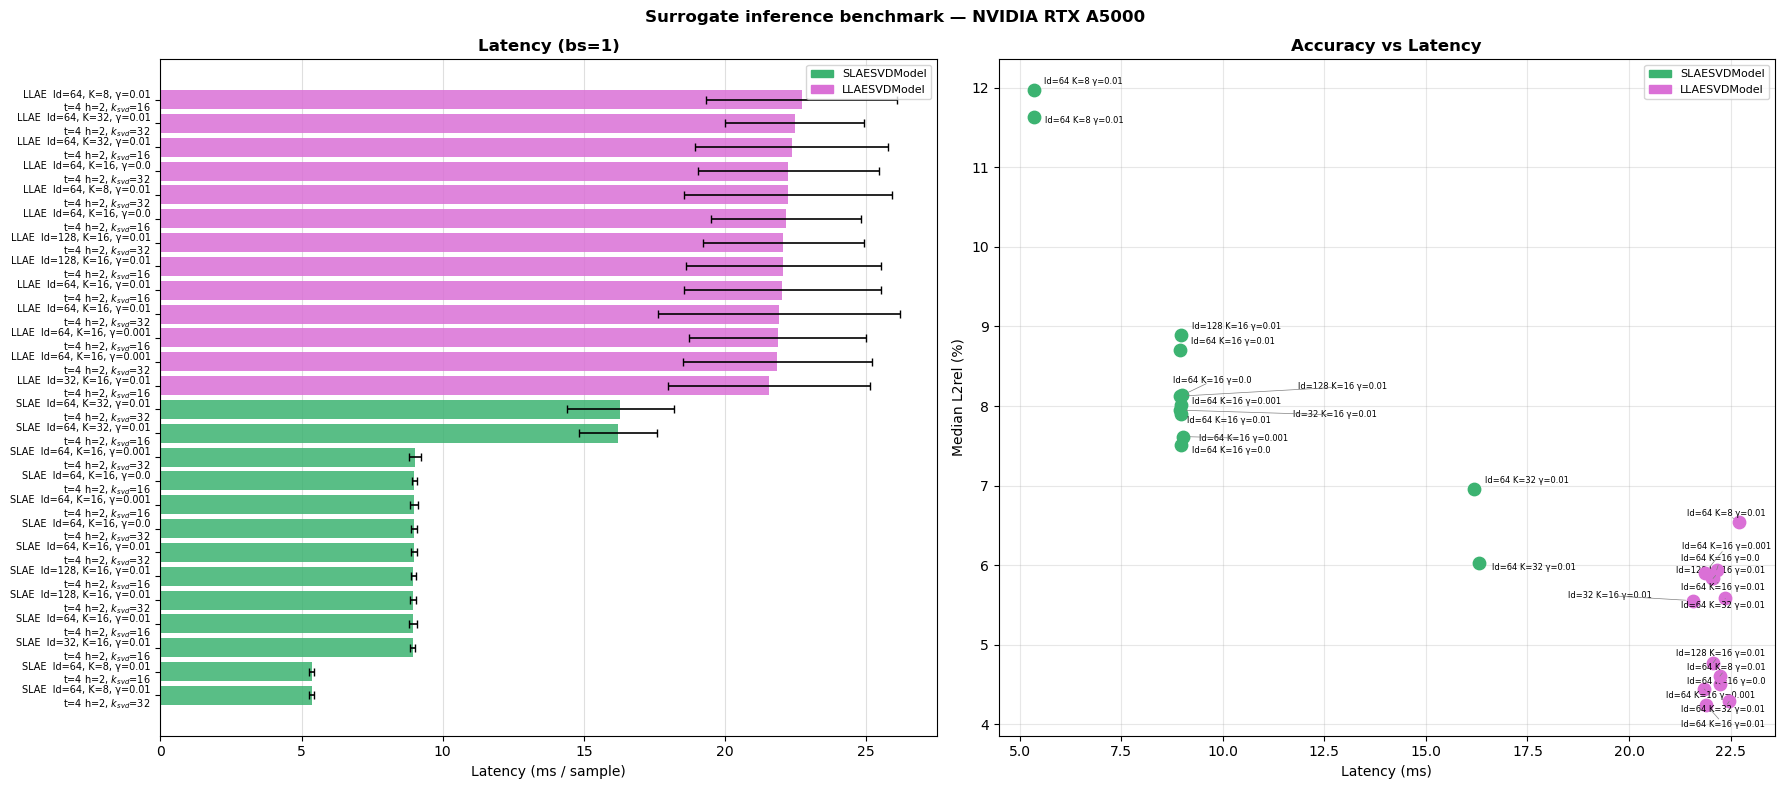

In [28]:

if bench and results:
    common = [n for n in bench if n in results]
    common_sorted = sorted(common, key=lambda n: bench[n]['lat_med'])

    from adjustText import adjust_text

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
    col = [PALETTE.get(model_types.get(n, ''), 'gray') for n in common_sorted]

    # ── Latency horizontal bar ────────────────────────────────────────────
    lats = [bench[n]['lat_med'] for n in common_sorted]
    stds = [bench[n]['lat_std']  for n in common_sorted]
    y    = np.arange(len(common_sorted))

    ax1.barh(y, lats, color=col, alpha=0.85, zorder=2)
    ax1.errorbar(lats, y, xerr=stds, fmt='none', color='black', capsize=3, linewidth=1.2, zorder=3)
    ax1.set_yticks(y)
    ax1.set_yticklabels([_pretty_name(n) for n in common_sorted], fontsize=7)
    ax1.set_xlabel('Latency (ms / sample)')
    ax1.set_title('Latency (bs=1)', fontweight='bold')
    ax1.grid(axis='x', alpha=0.4, zorder=0)

    # ── Accuracy vs latency scatter ───────────────────────────────────────
    def _scatter_label(name):
        m = _SURR_PAT.match(name)
        if not m: return name
        sm = _AE_STEM_PAT.match(m.group('ae_stem'))
        if not sm: return name
        return f'ld={sm.group("ld")} K={sm.group("K")} γ={float(sm.group("g"))}'

    texts = []
    for n in common:
        xp = bench[n]['lat_med']
        yp = np.median(results[n])
        ax2.scatter(xp, yp,
                    color=PALETTE.get(model_types.get(n, ''), 'gray'),
                    s=80, zorder=3)
        texts.append(ax2.text(xp, yp, _scatter_label(n), fontsize=6))

    adjust_text(texts, ax=ax2,
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.5, shrinkA=5, shrinkB=5),
                expand_points=(2.0, 2.0), expand_text=(1.5, 1.5))

    ax2.set_xlabel('Latency (ms)')
    ax2.set_ylabel('Median L2rel (%)')
    ax2.set_title('Accuracy vs Latency', fontweight='bold')
    ax2.grid(alpha=0.3)

    from matplotlib.patches import Patch
    legend_handles = [Patch(color=c, label=k) for k, c in PALETTE.items() if k in model_types.values()]
    for ax in (ax1, ax2):
        ax.legend(handles=legend_handles, fontsize=8)

    gpu_name = torch.cuda.get_device_name(0) if device == 'cuda' else 'CPU'
    fig.suptitle(f'Surrogate inference benchmark — {gpu_name}', fontweight='bold')
    fig.tight_layout()
    plt.show()
